In [2]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np

In [3]:
folder_path = 'Boca3Jun26_200mW_200mW_2932cm_10x_G70_CARS_200x200_700x700_1us'
txt_files = [f for f in os.listdir('Boca3Jun26_200mW_200mW_2932cm_10x_G70_CARS_200x200_700x700_1us') if f.endswith('.txt')]
all_images_flattened = []
# print(txt_files)

In [4]:
for file_name in txt_files:
    files_path = os.path.join(folder_path, file_name)
    df = pd.read_csv(files_path, sep = r'\s+', decimal = ',', header = None)
    raw_array = df.to_numpy().flatten()
    if raw_array.size == 490000:
        raw_array = (raw_array-raw_array.min())/(raw_array.max()-raw_array.min())
        all_images_flattened.append(raw_array)

In [5]:
X_pca = np.vstack(all_images_flattened)
n_comp = min(X_pca.shape[0]-1, 5)
pca = PCA(n_components=n_comp, random_state=42)
X_pca_transformed = pca.fit_transform(X_pca)
X_pca_projected = pca.inverse_transform(X_pca_transformed)

clean_pca_image = X_pca_projected[0].reshape(700,700)

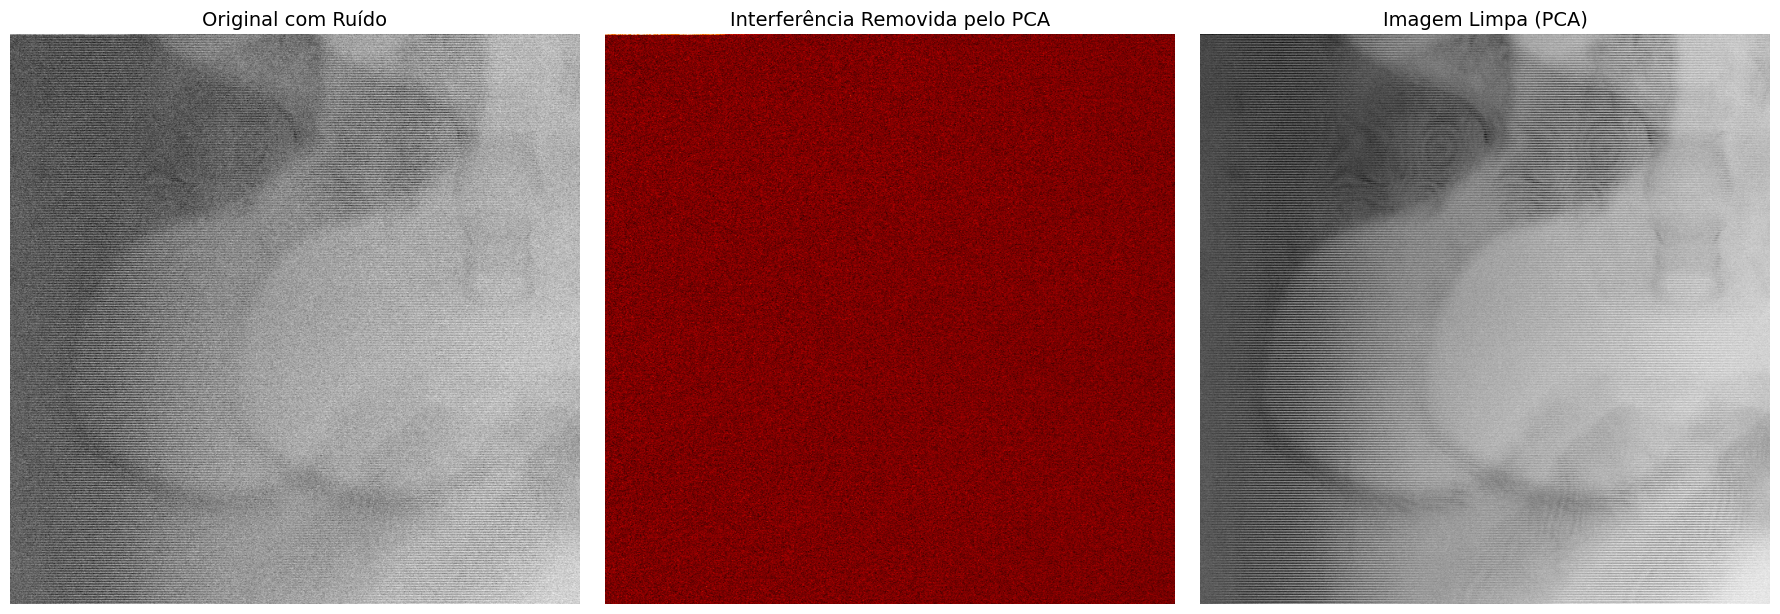

In [18]:
# 3. Pegar a imagem original correspondente (com ruído) para podermos comparar
original_noisy_image = X_pca[0].reshape(700, 700)

# 4. Isolar o ruído que o PCA removeu
pca_noise_isolated = original_noisy_image - clean_pca_image

# 5. Gerar os gráficos para a sua apresentação
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Painel 1: Imagem Original com Ruído CARS
axes[0].imshow(original_noisy_image, cmap='grey')
axes[0].set_title('Original com Ruído', fontsize=14)
axes[0].axis('off')

# Painel 2: O que o PCA identificou como ruído/variação descartada
# Usamos o mapa 'bwr' (Blue-White-Red) para destacar flutuações positivas e negativas
axes[1].imshow(pca_noise_isolated, cmap='gist_heat')
axes[1].set_title('Interferência Removida pelo PCA', fontsize=14)
axes[1].axis('off')

# Painel 3: Imagem Reconstruída e Filtrada pelo PCA
axes[2].imshow(clean_pca_image, cmap='grey')
axes[2].set_title('Imagem Limpa (PCA)', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('Resultados_CARS_PCA.png', dpi=300) # Salva o gráfico em alta resolução para os seus slides
plt.show()